---
title: Lesson 1
subtitle: Getting to grips with Python, Jupyter Notebooks, and Introduction to Fluid Dynamics
author:
  - name: Charlotte McMain
    affiliations: Oundle School
    email: cem@oundleschool.org.uk
license:
  code: MIT
date: 2026-04-11
---

In order to better understand aerodynamics, we need to learn some computational fluid dynamics. 

Our goal over the next 6 lessons is to be able to create our own simulation of fluid flow past a cylinder:

![SegmentLocal](/Users/license/Desktop/CharlotteMcMain.github.io/images/1*wqcb10sKNKP_B_ihsfS8Tw.gif "segment")

However, in order to get there, we need to learn some physics and some computing. 

Today, we will:
- Get to grips with Python and Jupyter Notebooks
- Make our own simulation of a single particle

First, let's try to generate a particle at a fixed position.

We can define the starting position of the particle using *Cartesian* coordinates ($x$ and $y$):

In [1]:
x_0 = 5
y_0 = 5

Or, we can write it more concisely by using an array:

In [2]:
x_0, y_0 = 5, 5

We also need to give it an initial speed:

In [3]:
v = 2 # m/s

Now, for our animation, we need a box for it to be contained in:

In [4]:
x_start = 0
x_end = 10
y_start = 10
y_end = -20

We can create a figure and axes for the animation:

(We need to install the matplotlib package to allow us to plot)

In [5]:
import matplotlib.pyplot as plt

fig, ax_plot = plt.subplots() # create a figure and axis for plotting
plt.close(fig)
ax_plot.set_xlim(x_start, x_end) # set limits for x-axis
ax_plot.set_ylim(y_end, y_start) # set limits for y-axis

(-20.0, 10.0)

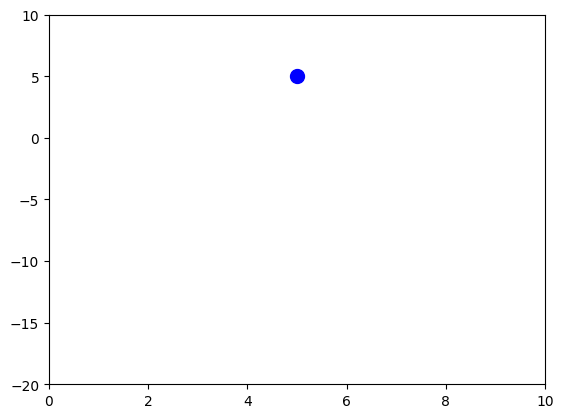

In [6]:
particle, = ax_plot.plot([x_0], [y_0], 'bo', markersize=10) # create a blue particle
fig


Now we can make our particle move the right with our velocity of $2\ \text{m s}^{-1}$.

To do this, we need to **discretise** our equation of motion. This means turning something continuous into separate, distinct steps or values. 

So, in reality, we know that the displacement of the particle will be changing continously and smoothly, but we can *discretise* it by a specific time-step so we can update our animation by this position for each step.

Essentially, creating a displacement-time graph:

| Time | Displacement  |
|:----:|:-------------:|
| 0    | 5             |
| 1    | ?             |
| 2    | ?             |
| 3    | ?             |
| 4    | ?             |
| 5    | ?             |

And then we will update each frame with the new displacement and when we play it in rapid succession it will look like an animation!

So, how do we find out the new displacement?

We know:
- $x_0 = 5$
- $v = 2$
- $\Delta t = 1$


We can use our equations of motion:
\begin{equation}
    v=\frac{dx}{dt}\ \rightarrow\ dx=v\ dt\ \rightarrow\ \Delta x=v\Delta t
\end{equation}

\begin{equation}
    \therefore\ \Delta x=x_1-x_0\ \rightarrow\ x_1=x_0+v\Delta t
\end{equation}

We could write out each value using this equation, e.g.:

$x_0 = 5\\
x_1 = x_0 + (v*dt)\\
x_2 = x_1 + (v*dt)\\
x_3 = x_2 + (v*dt)$

But, in order to plot long animations with smaller and smaller timesteps, we want to automate this loop. 

We can write the loop using a function:

In [7]:
dt = 0.05
particle, = ax_plot.plot([], [], 'bo', markersize=10)

x, y = x_0, y_0

def update(frame):
    global x, y

    x, y = x_0, y_0

    for _ in range(frame):
        x += v * dt
    
    particle.set_data([x], [y])
    return particle,

In [8]:
import matplotlib.animation as animation
from IPython.display import HTML

def init():
    particle.set_data([x_0], [y_0])
    return particle,

ani = animation.FuncAnimation(fig, update, frames=50, init_func=init, interval=50, blit=True)

HTML(ani.to_jshtml())

Now, let's add in movement in the y-direction. Make the particle move with $5\ \text{m s}^{-1}$ velocity in the y-direction:


In [9]:
v_x_0 = 2
v_y_0 = 5

x, y = x_0, y_0

def update(frame):
    global x, y, v_x, v_y

    x, y = x_0, y_0
    v_x, v_y = v_x_0, v_y_0

    for _ in range(frame):
        x += v_x * dt
        y += v_y * dt

    particle.set_data([x], [y])
    return particle,

ani = animation.FuncAnimation(fig, update, frames=25, init_func=init, interval=50, blit=True)

HTML(ani.to_jshtml())

Now, we can make it more realistic by adding gravity as an acceleration in the y-direction. Again, we need to use our equations of motion:

\begin{equation}
    a=\frac{dv}{dt}\ \rightarrow\ dv=a\ dt\ \rightarrow\ \Delta v=a\Delta t
\end{equation}

\begin{equation}
    \therefore\ \Delta v=v_1-v_0\ \rightarrow\ v_1=v_0+a\Delta t
\end{equation}

Rewrite the function to add in a y-direction acceleration:

In [10]:
v_x_0 = 2
v_y_0 = 5
a_y = -9.81

x, y = x_0, y_0
v_y = v_y_0

def update(frame):
    global x, y, v_y

    x, y = x_0, y_0
    v_x, v_y = v_x_0, v_y_0

    for _ in range(frame):
        v_y += a_y * dt
        x += v_x * dt
        y += v_y * dt

    particle.set_data([x], [y])
    return particle,

ani = animation.FuncAnimation(fig, update, frames=60, init_func=init, interval=50, blit=True)

HTML(ani.to_jshtml())

Let's add code to make the boundaries solid so that the particle bounces. How could we do this?

In [11]:
x, y = x_0, y_0
v_x, v_y = v_x_0, v_y_0

def update(frame):
    global x, y, v_x, v_y

    x, y = x_0, y_0
    v_x, v_y = v_x_0, v_y_0

    for _ in range(frame):
        v_y += a_y * dt
        x += v_x * dt
        y += v_y * dt

        if x <= x_start or x >= x_end:
            v_x = -v_x
        if y <= y_end or y >= y_start:
            v_y = -v_y

    particle.set_data([x], [y])
    return particle,

ani = animation.FuncAnimation(fig, update, frames=200, init_func=init, interval=50, blit=True)

HTML(ani.to_jshtml())


Okay, we've got the basics. Now you could extend your animation by:
- Make it more realistic by adding air resistance.
- Add a trail to the particle's path by storing its previous positions and plotting them as a line behind the particle.
- Introduce multiple particles with different initial conditions and colours to visualize their trajectories simultaneously.
- Add an object for the particle to collide with.
- Implement user controls to adjust parameters like initial velocity, acceleration, or time step in real-time.